In [1]:
print("Image Classification Project Started!")

Image Classification Project Started!


In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
import tensorflow as tf

base_dir = r"C:\Users\girga\Desktop\PetImages"

image_size = (160, 160)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

print("Classes:", train_ds.class_names)

Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.
Classes: ['Cat', 'Dog']


In [4]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(160, 160, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 158, 158, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 79, 79, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 77, 77, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 38, 38, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 36, 36, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 18, 18, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 41472)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       5,308,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,401,921 (20.61 MB)

 Trainable params: 5,401,921 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5


C:\Users\girga\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


278/625 ━━━━━━━━━━━━━━━━━━━━ 2:10 375ms/step - accuracy: 0.5673 - loss: 0.6881

InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Input size should match (header_size + row_size * abs_height) but they differ by 2
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_2220]

In [6]:
import os
from PIL import Image

base_dir = r"C:\Users\girga\Desktop\PetImages"

removed = 0

for folder in ["Cat", "Dog"]:
    folder_path = os.path.join(base_dir, folder)

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            os.remove(file_path)
            removed += 1

print("Corrupted images removed:", removed)

C:\Users\girga\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupted images removed: 0


In [7]:
import os

base_dir = r"C:\Users\girga\Desktop\PetImages"

bad_files = []

for folder in ["Cat", "Dog"]:
    folder_path = os.path.join(base_dir, folder)

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        try:
            with open(file_path, "rb") as f:
                header = f.read(10)

            if b"JFIF" not in header:
                bad_files.append(file_path)

        except Exception:
            bad_files.append(file_path)

print("Bad files found:", len(bad_files))

for file in bad_files[:20]:
    print(file)

Bad files found: 1800
C:\Users\girga\Desktop\PetImages\Cat\10007.jpg
C:\Users\girga\Desktop\PetImages\Cat\10019.jpg
C:\Users\girga\Desktop\PetImages\Cat\10036.jpg
C:\Users\girga\Desktop\PetImages\Cat\10037.jpg
C:\Users\girga\Desktop\PetImages\Cat\10054.jpg
C:\Users\girga\Desktop\PetImages\Cat\10070.jpg
C:\Users\girga\Desktop\PetImages\Cat\10073.jpg
C:\Users\girga\Desktop\PetImages\Cat\10077.jpg
C:\Users\girga\Desktop\PetImages\Cat\10117.jpg
C:\Users\girga\Desktop\PetImages\Cat\10125.jpg
C:\Users\girga\Desktop\PetImages\Cat\10133.jpg
C:\Users\girga\Desktop\PetImages\Cat\10135.jpg
C:\Users\girga\Desktop\PetImages\Cat\10157.jpg
C:\Users\girga\Desktop\PetImages\Cat\10187.jpg
C:\Users\girga\Desktop\PetImages\Cat\10197.jpg
C:\Users\girga\Desktop\PetImages\Cat\10209.jpg
C:\Users\girga\Desktop\PetImages\Cat\10219.jpg
C:\Users\girga\Desktop\PetImages\Cat\10235.jpg
C:\Users\girga\Desktop\PetImages\Cat\1024.jpg
C:\Users\girga\Desktop\PetImages\Cat\10244.jpg


In [8]:
import os

base_dir = r"C:\Users\girga\Desktop\PetImages"

bad_files = []

for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join(base_dir, folder_name)

    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)

        try:
            with open(fpath, "rb") as fobj:
                is_jfif = b"JFIF" in fobj.peek(10)
        except Exception:
            is_jfif = False

        if not is_jfif:
            bad_files.append(fpath)

print("Bad files found:", len(bad_files))
print("First 10 bad files:")

for file in bad_files[:10]:
    print(file)

Bad files found: 1576
First 10 bad files:
C:\Users\girga\Desktop\PetImages\Cat\10019.jpg
C:\Users\girga\Desktop\PetImages\Cat\10036.jpg
C:\Users\girga\Desktop\PetImages\Cat\10037.jpg
C:\Users\girga\Desktop\PetImages\Cat\10070.jpg
C:\Users\girga\Desktop\PetImages\Cat\10073.jpg
C:\Users\girga\Desktop\PetImages\Cat\10077.jpg
C:\Users\girga\Desktop\PetImages\Cat\10117.jpg
C:\Users\girga\Desktop\PetImages\Cat\10125.jpg
C:\Users\girga\Desktop\PetImages\Cat\10133.jpg
C:\Users\girga\Desktop\PetImages\Cat\10135.jpg


In [9]:
for file_path in bad_files:
    os.remove(file_path)

print("Bad files removed:", len(bad_files))

Bad files removed: 1576


In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

print("Classes:", train_ds.class_names)

Found 23422 files belonging to 2 classes.
Using 18738 files for training.
Found 23422 files belonging to 2 classes.
Using 4684 files for validation.
Classes: ['Cat', 'Dog']


In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 239s 408ms/step - accuracy: 0.6857 - loss: 0.5938 - val_accuracy: 0.7156 - val_loss: 0.5545
Epoch 2/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 246s 420ms/step - accuracy: 0.7768 - loss: 0.4753 - val_accuracy: 0.7886 - val_loss: 0.4521
Epoch 3/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 250s 426ms/step - accuracy: 0.8218 - loss: 0.4010 - val_accuracy: 0.8179 - val_loss: 0.4161
Epoch 4/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 246s 419ms/step - accuracy: 0.8587 - loss: 0.3270 - val_accuracy: 0.8307 - val_loss: 0.4079
Epoch 5/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 233s 397ms/step - accuracy: 0.8905 - loss: 0.2622 - val_accuracy: 0.8143 - val_loss: 0.4281


In [12]:
test_loss, test_accuracy = model.evaluate(val_ds)

print("Validation Loss:", test_loss)
print("Validation Accuracy:", test_accuracy)

147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step - accuracy: 0.8143 - loss: 0.4281
Validation Loss: 0.4281245768070221
Validation Accuracy: 0.8142613172531128


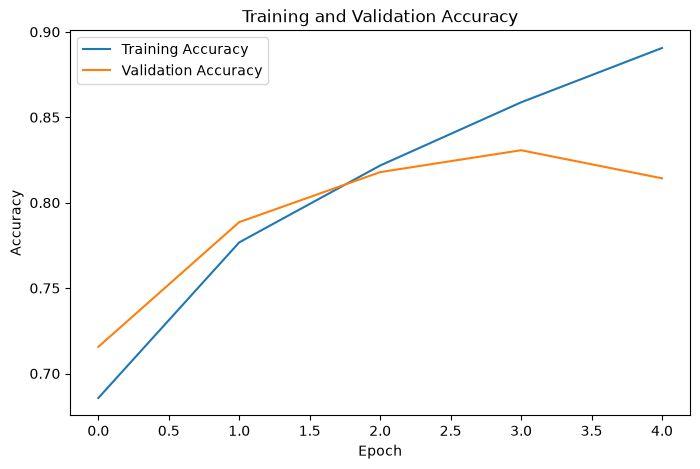

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

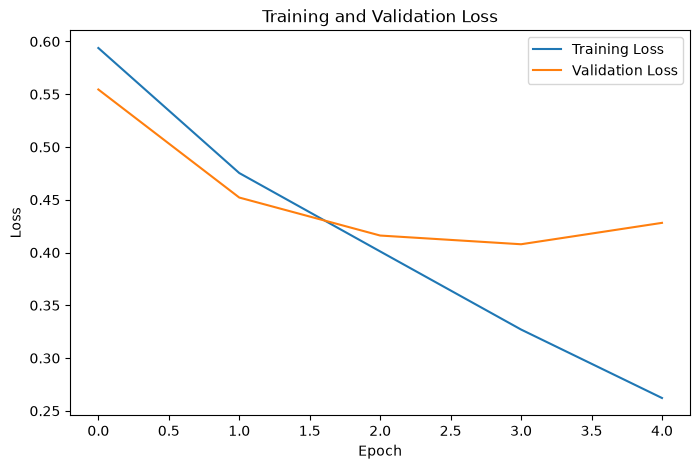

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [15]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

def predict_image(image_path):
    img = load_img(image_path, target_size=(160, 160))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)[0][0]

    if prediction >= 0.5:
        result = "Dog 🐶"
        confidence = prediction * 100
    else:
        result = "Cat 🐱"
        confidence = (1 - prediction) * 100

    print("Prediction:", result)
    print("Confidence:", round(confidence, 2), "%")

print("CAT IMAGE:")
predict_image(r"C:\Users\girga\Desktop\cat.jpg")

print("\nDOG IMAGE:")
predict_image(r"C:\Users\girga\Desktop\dog.jpg")

CAT IMAGE:
Prediction: Cat 🐱
Confidence: 97.95 %

DOG IMAGE:
Prediction: Dog 🐶
Confidence: 99.94 %


In [16]:
model.save(r"C:\Users\girga\Desktop\cat_dog_classifier.keras")

print("Model saved successfully!")

Model saved successfully!


In [17]:
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

# Load the saved model
model = tf.keras.models.load_model(
    r"C:\Users\girga\Desktop\cat_dog_classifier.keras"
)

image_path = input("Enter image path: ")

img = load_img(image_path, target_size=(160, 160))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)[0][0]

if prediction >= 0.5:
    print("Prediction: Dog 🐶")
    print("Confidence:", round(prediction * 100, 2), "%")
else:
    print("Prediction: Cat 🐱")
    print("Confidence:", round((1 - prediction) * 100, 2), "%")
    

Enter image path:  C:\Users\girga\Desktop\cat.jpg


Prediction: Cat 🐱
Confidence: 97.95 %


# Image Classification Using CNN

## Objective

The objective of this project is to develop an image classification model using Convolutional Neural Networks (CNN) to classify images into two basic categories: Cats and Dogs. The model is trained using the Cats and Dogs dataset and can predict the class of a new image.

SyntaxError: invalid character '×' (U+00D7) (2587293668.py, line 23)

SyntaxError: invalid syntax (4148716791.py, line 13)

SyntaxError: invalid syntax (4148716791.py, line 13)

## Technologies Used

- Python
- TensorFlow
- Keras
- NumPy
- Matplotlib
- Pillow
- JupyterLab

## Dataset Information

The project uses the Cats and Dogs image dataset.

The dataset contains two classes:
- Cat
- Dog

The images were divided into:
- Training: 18,738 images
- Validation: 4,684 images

Images were resized to 160 x 160 pixels before being given to the CNN model.


## CNN Model Architecture

A Convolutional Neural Network (CNN) is used for image classification.

The model consists of the following layers:

1. Rescaling layer
2. Convolutional layer with 32 filters
3. Max Pooling layer
4. Convolutional layer with 64 filters
5. Max Pooling layer
6. Convolutional layer with 128 filters
7. Max Pooling layer
8. Flatten layer
9. Dense layer with 128 neurons
10. Dropout layer
11. Output layer with 1 neuron and sigmoid activation

The sigmoid activation function produces a value between 0 and 1, which is used to classify the image as either Cat or Dog.

## Training Results

The CNN model was trained for 5 epochs using the training dataset.

The training accuracy improved from 68.57% in the first epoch to 89.05% in the fifth epoch.

The highest validation accuracy was 83.07% in the fourth epoch.

Final evaluation on the validation dataset gave:

- Validation Accuracy: 81.43%
- Validation Loss: 0.4281

The model was also tested on two new images:

- Cat image: 97.95% confidence
- Dog image: 99.94% confidence

## Conclusion

In this project, a Convolutional Neural Network (CNN) was successfully developed for image classification.

The model was trained to classify images into two categories: Cat and Dog. After training for 5 epochs, the model achieved a final validation accuracy of 81.43%.

The model successfully predicted new cat and dog images with high confidence. The trained model was also saved in Keras format for future use.

This project demonstrates how deep learning and CNNs can be used for practical image classification applications.

In [22]:
import tensorflow as tf

loaded_model = tf.keras.models.load_model(
    r"C:\Users\girga\Desktop\cat_dog_classifier.keras"
)

print("Saved model loaded successfully!")

Saved model loaded successfully!


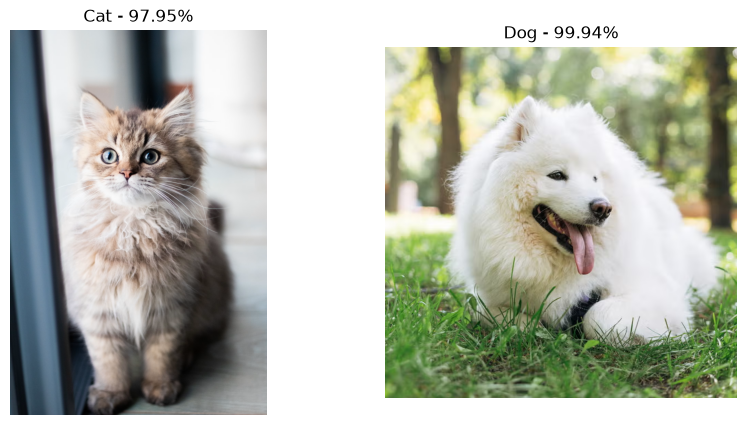

In [23]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

cat_path = r"C:\Users\girga\Desktop\cat.jpg"
dog_path = r"C:\Users\girga\Desktop\dog.jpg"

def get_prediction(image_path):
    img = load_img(image_path, target_size=(160, 160))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)[0][0]

    if prediction >= 0.5:
        label = "Dog"
        confidence = prediction * 100
    else:
        label = "Cat"
        confidence = (1 - prediction) * 100

    return label, confidence

cat_label, cat_conf = get_prediction(cat_path)
dog_label, dog_conf = get_prediction(dog_path)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(load_img(cat_path))
plt.title(f"{cat_label} - {cat_conf:.2f}%")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(load_img(dog_path))
plt.title(f"{dog_label} - {dog_conf:.2f}%")
plt.axis("off")

plt.show()

## Results

The trained CNN model was successfully tested on new images.

### Model Performance

- Final Validation Accuracy: 81.43%
- Best Validation Accuracy: 83.07%
- Training Accuracy: 89.05%
- Validation Loss: 0.4281

### Prediction Results

The model successfully classified the test images:

- Cat Image → Cat (97.95% confidence)
- Dog Image → Dog (99.94% confidence)

The results show that the CNN model can successfully distinguish between Cat and Dog images.

## Project Summary

This project developed a CNN-based image classification system using TensorFlow and Keras. The model was trained on a Cats and Dogs dataset and learned to classify images into two categories: Cat and Dog.

The dataset was cleaned by removing corrupted images, resized to 160 × 160 pixels, and divided into training and validation datasets. A CNN model containing convolutional, pooling, dense, and dropout layers was then trained for 5 epochs.

The model achieved a final validation accuracy of 81.43%, with the highest validation accuracy of 83.07% during training. It successfully classified new test images as Cat and Dog with high confidence.

The trained model was saved in Keras format and can be reused to classify new images.

### Technologies Used

* Python
* TensorFlow
* Keras
* NumPy
* Matplotlib
* Pillow
* JupyterLab

### Project Outcome

The project successfully demonstrates how a Convolutional Neural Network can be used for practical binary image classification.


In [1]:
import tensorflow as tf

model = tf.keras.models.load_model(
    r"C:\Users\girga\Desktop\cat_dog_classifier.keras"
)

print("Model loaded successfully! ✅")

Model loaded successfully! ✅


In [2]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

image_path = r"C:\Users\girga\Desktop\cat.jpg"

img = load_img(image_path, target_size=(160, 160))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)[0][0]

if prediction >= 0.5:
    print("Prediction: Dog 🐶")
    print("Confidence:", round(prediction * 100, 2), "%")
else:
    print("Prediction: Cat 🐱")
    print("Confidence:", round((1 - prediction) * 100, 2), "%")

Prediction: Cat 🐱
Confidence: 97.95 %


In [3]:
image_path = r"C:\Users\girga\Desktop\test_image.jpg"

img = load_img(image_path, target_size=(160, 160))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)[0][0]

if prediction >= 0.5:
    print("Prediction: Dog 🐶")
    print("Confidence:", round(prediction * 100, 2), "%")
else:
    print("Prediction: Cat 🐱")
    print("Confidence:", round((1 - prediction) * 100, 2), "%")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\girga\\Desktop\\test_image.jpg'

In [4]:
image_path = r"C:\Users\girga\Desktop\dog.jpg"

img = load_img(image_path, target_size=(160, 160))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)[0][0]

if prediction >= 0.5:
    print("Prediction: Dog 🐶")
    print("Confidence:", round(prediction * 100, 2), "%")
else:
    print("Prediction: Cat 🐱")
    print("Confidence:", round((1 - prediction) * 100, 2), "%")"

img = load_img(image_path, target_size=(160, 160))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)[0][0]

if prediction >= 0.5:
    print("Prediction: Dog 🐶")
    print("Confidence:", round(prediction * 100, 2), "%")
else:
    print("Prediction: Cat 🐱")
    print("Confidence:", round((1 - prediction) * 100, 2), "%")

SyntaxError: unterminated string literal (detected at line 14) (2006351377.py, line 14)

In [5]:
image_path = r"C:\Users\girga\Desktop\dog.jpg"

img = load_img(image_path, target_size=(160, 160))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)[0][0]

if prediction >= 0.5:
    print("Prediction: Dog 🐶")
    print("Confidence:", round(prediction * 100, 2), "%")
else:
    print("Prediction: Cat 🐱")
    print("Confidence:", round((1 - prediction) * 100, 2), "%")

Prediction: Dog 🐶
Confidence: 99.94 %


In [1]:
image_path = input("Enter the full image path: ")
predict_image(image_path)

Enter the full image path:  C:\Users\girga\Desktop\cat.jpg


NameError: name 'predict_image' is not defined

In [2]:
image_path = input("Enter the full image path: ")
predict_image(image_path)


Enter the full image path:  C:\Users\girga\Desktop\dog.jpg


NameError: name 'predict_image' is not defined

In [3]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

def predict_image(image_path):
    img = load_img(image_path, target_size=(160, 160))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)[0][0]

    if prediction >= 0.5:
        result = "Dog 🐶"
        confidence = prediction * 100
    else:
        result = "Cat 🐱"
        confidence = (1 - prediction) * 100

    print("Prediction:", result)
    print("Confidence:", round(confidence, 2), "%")

In [4]:
image_path = input("Enter the full image path: ")
predict_image(image_path)

Enter the full image path:  C:\Users\girga\Desktop\cat.jpg


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\girga\\Desktop\\cat.jpg'

In [5]:
import os

print(os.path.exists(r"C:\Users\girga\Desktop\cat.jpg"))

False


In [6]:
predict_image(r"C:\Users\girga\Desktop\dog.jpg")

NameError: name 'model' is not defined

In [7]:
import tensorflow as tf

model = tf.keras.models.load_model(
    r"C:\Users\girga\Desktop\cat_dog_classifier.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


In [8]:
predict_image(r"C:\Users\girga\Desktop\dog.jpg")

Prediction: Dog 🐶
Confidence: 99.94 %


In [ ]:
while True:
    image_path = input("Enter image path (or type 'exit' to stop): ")

    if image_path.lower() == "exit":
        print("Prediction session ended!")
        break

    try:
        predict_image(image_path)
    except FileNotFoundError:
        print("Image not found. Please check the path and try again.")
    except Exception as e:
        print("Error:", e)

In [1]:
predict_image(r""C:\Users\girga\Desktop\PetImages\Dog"")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1316271372.py, line 1)

In [2]:
predict_image(r""C:\Users\girga\Desktop\PetImages\Cat\64.jpg")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1537713666.py, line 1)

In [3]:
redict_image(r"C:\Users\girga\Desktop\dog.jpg")

NameError: name 'redict_image' is not defined

In [1]:
predict_image(r"C:\Users\girga\Desktop\dog.jpg")

NameError: name 'predict_image' is not defined

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

# Load your saved model
model = tf.keras.models.load_model(
    r"C:\Users\girga\Desktop\cat_dog_classifier.keras"
)

# Define the prediction function
def predict_image(image_path):
    img = load_img(image_path, target_size=(160, 160))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)[0][0]

    if prediction >= 0.5:
        result = "Dog 🐶"
        confidence = prediction * 100
    else:
        result = "Cat 🐱"
        confidence = (1 - prediction) * 100

    print("Prediction:", result)
    print("Confidence:", round(float(confidence), 2), "%")

print("Model and prediction function are ready!")

ValueError: File not found: filepath=C:\Users\girga\Desktop\cat_dog_classifier.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[2], line 6
      2 import tensorflow as tf
      3 from tensorflow.keras.utils import load_img, img_to_array
      4 
      5 # Load your saved model
----> 6 model = tf.keras.models.load_model(
      7     r"C:\Users\girga\Desktop\cat_dog_classifier.keras"
      8 )
      9 

File ~\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_api.py:214, in load_model(filepath, custom_objects, compile, safe_mode)
    206     return _load_model_from_orbax_checkpoint(
    207         filepath,
    208         custom_objects=custom_objects,
    209         compile=compile,
    210         safe_mode=safe_mode,
    211     )
    213 elif str(filepath).endswith(".keras"):
--> 214     raise ValueError(
    215         f"File not found: filepath={filepath}. "
    216         "Please ensure the file is an accessible `.keras` "
    217         "zip file."
    218     )
    219 else:
    220     raise ValueError(
    221         f"File format not supported: filepath={filepath}. "
    222         "Keras 3 only supports V3 `.keras` files, "
   (...)    231         "might have a different name)."
    232     )

ValueError: File not found: filepath=C:\Users\girga\Desktop\cat_dog_classifier.keras. Please ensure the file is an accessible `.keras` zip file.

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

# Load your model from the ashra folder
model = tf.keras.models.load_model(
    r"C:\Users\girga\Desktop\ashra\cat_dog_classifier.keras"
)

def predict_image(image_path):
    img = load_img(image_path, target_size=(160, 160))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)[0][0]

    if prediction >= 0.5:
        result = "Dog 🐶"
        confidence = prediction * 100
    else:
        result = "Cat 🐱"
        confidence = (1 - prediction) * 100

    print("Prediction:", result)
    print("Confidence:", round(float(confidence), 2), "%")

print("Model loaded and prediction function is ready!")

Model loaded and prediction function is ready!


In [4]:
predict_image(r"C:\Users\girga\Desktop\ashra\dog.jpg")

Prediction: Dog 🐶
Confidence: 99.94 %


In [5]:
predict_image(r"C:\Users\girga\Desktop\ashra\test_image.jpg.jpg"")

SyntaxError: unterminated string literal (detected at line 1) (1343155513.py, line 1)

In [6]:
predict_image(r"C:\Users\girga\Desktop\ashra\test_image.jpg.jpg"

SyntaxError: incomplete input (1788872929.py, line 1)

In [7]:
predict_image(r"C:\Users\girga\Desktop\ashra\test_image.jpg.jpg")

Prediction: Cat 🐱
Confidence: 97.95 %


In [8]:
predict_image(r"C:\Users\girga\Desktop\ashra\dog.jpg")

Prediction: Dog 🐶
Confidence: 99.94 %


In [9]:
predict_image(r"C:\Users\girga\Desktop\ashra\test_image.jpg.jpg")

Prediction: Cat 🐱
Confidence: 97.95 %
